# Dropout Regularization

This Colab demonstrates dropout regularization on an MNIST CNN model. It trains models with 0%, 20%, and 50% dropout and compares validation accuracy.

## Setup & Imports

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

## Load Dataset

In [ ]:
# Load dataset (MNIST for simplicity)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Normalize Images

In [ ]:
# Normalize images to [0,1] range
x_train, x_test = x_train / 255.0, x_test / 255.0

## Model Compatibility

In [ ]:
# Expand dimensions for CNN compatibility
x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]

## Model Creation

In [ ]:
# Function to create model with dropout
def create_model(dropout_rate=0.0):
    model = keras.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(10, activation='softmax')
    ])
    return model

## Train Models

In [ ]:
# Train models with different dropout rates
dropout_rates = [0.0, 0.2, 0.5]
histories = {}

for rate in dropout_rates:
    print(f"Training model with dropout rate: {rate}")
    model = create_model(dropout_rate=rate)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test), batch_size=64, verbose=1)
    histories[f"Dropout {rate}"] = history

Training model with dropout rate: 0.0


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 38s 38ms/step - accuracy: 0.8884 - loss: 0.3736 - val_accuracy: 0.9848 - val_loss: 0.0465
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 32s 34ms/step - accuracy: 0.9852 - loss: 0.0488 - val_accuracy: 0.9860 - val_loss: 0.0441
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.9891 - loss: 0.0332 - val_accuracy: 0.9916 - val_loss: 0.0265
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 32s 34ms/step - accuracy: 0.9931 - loss: 0.0232 - val_accuracy: 0.9859 - val_loss: 0.0435
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.9939 - loss: 0.0185 - val_accuracy: 0.9905 - val_loss: 0.0293
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.9962 - loss: 0.0129 - val_accuracy: 0.9896 - val_loss: 0.0363
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 35ms/step - accuracy: 0.9960 - loss: 0.0131 - val_accuracy: 0.9919 - val_loss: 0.0290
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 35ms/step - accuracy: 0.9974 - loss: 0.0087 - 

## Visualization

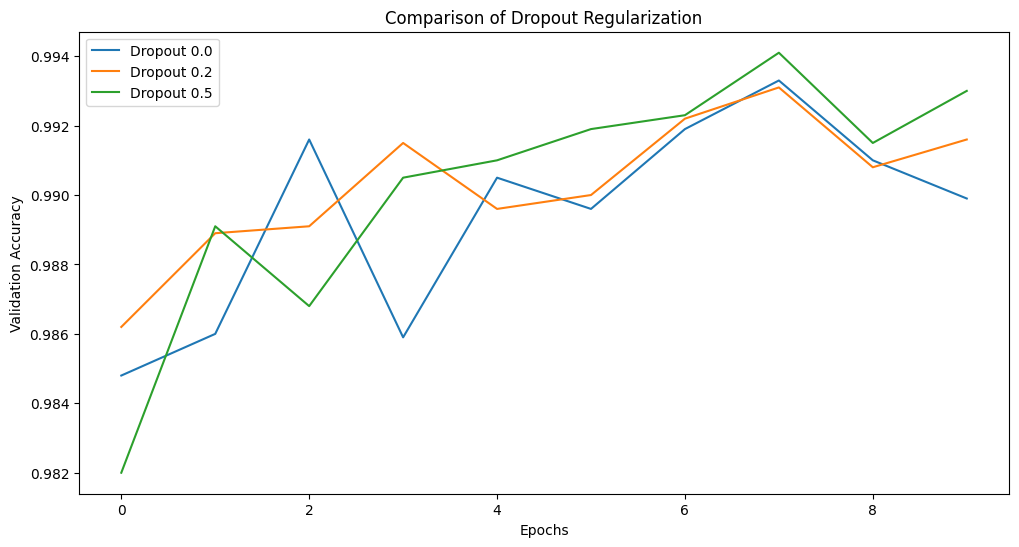

In [ ]:
# Plot training results
plt.figure(figsize=(12, 6))
for name, history in histories.items():
    plt.plot(history.history['val_accuracy'], label=name)
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('Comparison of Dropout Regularization')
plt.show()

Dropout Regularization

📘 Overview

This Colab notebook demonstrates the use of dropout regularization in a convolutional neural network (CNN) using TensorFlow and Keras. The model is trained on the MNIST dataset, and different dropout rates are tested to observe their effect on validation accuracy.

🧪 Objective

To explore how different dropout rates (0.0, 0.2, 0.5) impact model generalization and prevent overfitting.

🛠️ Implementation Details

Dataset: MNIST

Model: CNN with 2 convolutional layers and 1 dense layer

Dropout Layer: Applied before the final output layer

Dropout Rates Tested:

No Dropout (0.0)

Moderate Dropout (0.2)

Aggressive Dropout (0.5)

Training:

Epochs: 10

Batch Size: 64

Optimizer: Adam

Loss: Sparse Categorical Crossentropy

📈 Results

The model performance is compared using validation accuracy over epochs. A plot is generated to show how dropout affects generalization:

0.0 Dropout: High accuracy, but prone to overfitting.

0.2 Dropout: Balanced trade-off between accuracy and generalization.

0.5 Dropout: Better generalization, but may underfit slightly.

🧠 Insights

Dropout helps prevent the network from memorizing the training data.

Higher dropout rates provide more regularization, but can hurt performance if overused.

0.2 is often a good starting point for image-based tasks.
